# Computer Exercise 15.25 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.25 Sequential Decision Making — *Multi-Slip Curriculum for Cross-Slip Generalization*
> **풀이 일자**: Day 92
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **Problem 3.** Building on §15.24 (Problem 3) — where a policy trained at
> $p_{\text{train}}=0.10$ generalised poorly across $p_{\text{deploy}} \in \{0.05, 0.10, 0.20\}$ —
> introduce a **multi-slip curriculum** at training time and measure cross-slip deployment
> return under a *greedy* freeze. Compare two curricula: (a) **uniform** — sample
> $p_{\text{train}} \sim \mathcal U(\{0.05, 0.10, 0.20\})$ per episode; (b) **stagewise** —
> for the first third of training use $p = 0.05$, middle third $p = 0.10$, final third
> $p = 0.20$. Baselines: fixed-$p = 0.10$ training (§15.24 P3 reproduction). Report cross-slip
> tail-8 deployment return and the **generalisation gap**
> $\Gamma_c = \max_{p_d} R_c(p_d) - \min_{p_d} R_c(p_d)$.

### 한국어 풀이용 정리
훈련시 슬립을 **다양화** 하면 cross-slip generalization 이 개선되는지, 그리고 uniform vs
stagewise curriculum 이 유의미하게 다른지 관측. 세 조건 (fixed-0.10 / uniform / stagewise)
× 3 시드 × 800 step 훈련, freeze 후 $p_d \in \{0.05, 0.10, 0.20\}$ 각각 60 에피소드 배포.


## 2. 수학적 배경

### 2.1 훈련 curricula
- **fixed**: 모든 에피소드에서 $p_{\text{train}} = 0.10$ (§15.24 P3 baseline).
- **uniform**: 각 에피소드 시작 시 $p_{\text{train}} \sim \mathcal U(\{0.05, 0.10, 0.20\})$.
- **stagewise**: episode index $e$ 에 대해 $p_{\text{train}} = 0.05$ if $e < E/3$,
  $= 0.10$ if $E/3 \le e < 2E/3$, $= 0.20$ else.

### 2.2 지표
Cross-slip 배포 tail-8 return $R(p_d)$, 조건별
$\Gamma_c = \max_{p_d} R_c(p_d) - \min_{p_d} R_c(p_d)$,
평균 $\bar R_c = (1/3) \sum_{p_d} R_c(p_d)$.

### 2.3 학습기
Baseline (§15.24 P3 와 동일) — shared trunk (H=16) + per-action linear head, MSE 회귀,
$\varepsilon$-greedy. 훈련 curriculum 을 바꿔서 3 조건 학습.


## 3. 풀이 흐름

1. 확률적 chain MDP factory.
2. Baseline 학습기.
3. 세 curriculum 학습 (3 시드 × 800 step).
4. Freeze → $p_d \in \{0.05, 0.10, 0.20\}$ 각각 60 에피소드 greedy 배포.
5. tail-8 return, $\Gamma_c$ 계산, 표/그래프 요약.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_MASTER = 20260810

class ChainMDP:
    def __init__(self, n=5, p_slip=0.10, step_cost=-0.02, goal=1.0):
        self.n, self.p_slip, self.step_cost, self.goal = n, p_slip, step_cost, goal
    def reset(self):
        self.s = 0
        return self.s
    def step(self, a, rng):
        d = 1 if a == 1 else -1
        if rng.random() < self.p_slip:
            d = -d
        ns = int(np.clip(self.s + d, 0, self.n - 1))
        r  = self.goal if ns == self.n - 1 else self.step_cost
        done = ns == self.n - 1
        self.s = ns
        return ns, r, done

def make_trunk(seed, in_dim, H=16):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((in_dim, H)) * (1.0 / np.sqrt(in_dim))
    def trunk(x):
        return np.tanh(x @ W)
    return trunk, H

def onehot(s, n=5):
    x = np.zeros(n); x[s] = 1.0; return x


/tmp/mplcfg is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-90mykckj because there was an issue with the default path (/tmp/mplcfg); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
class Baseline:
    # Shared trunk + per-action linear head, MSE, epsilon-greedy.
    def __init__(self, seed, H=16, n_actions=2, in_dim=5, lr=0.05, eps=0.10, gamma=0.98):
        self.rng = np.random.default_rng(seed)
        self.trunk, self.H = make_trunk(seed, in_dim, H)
        self.W = 0.05 * self.rng.standard_normal((n_actions, H))
        self.lr, self.eps, self.gamma, self.na = lr, eps, gamma, n_actions
    def qhat(self, s):
        return self.W @ self.trunk(onehot(s))
    def act(self, s, greedy=False):
        if not greedy and self.rng.random() < self.eps:
            return int(self.rng.integers(0, self.na))
        return int(np.argmax(self.qhat(s)))
    def update(self, s, a, r, ns, done):
        h = self.trunk(onehot(s))
        y = r + (0.0 if done else self.gamma * np.max(self.qhat(ns)))
        td = y - self.W[a] @ h
        self.W[a] += self.lr * td * h


In [3]:
def train_curriculum(kind, seed, n_step=800):
    ag = Baseline(seed=seed)
    step = 0
    while step < n_step:
        if kind == "fixed":
            p = 0.10
        elif kind == "uniform":
            p = float(ag.rng.choice([0.05, 0.10, 0.20]))
        elif kind == "stagewise":
            p = 0.05 if step < n_step / 3 else (0.10 if step < 2 * n_step / 3 else 0.20)
        env = ChainMDP(p_slip=p)
        s = env.reset()
        for _ in range(50):
            if step >= n_step: break
            a = ag.act(s)
            ns, r, done = env.step(a, ag.rng)
            ag.update(s, a, r, ns, done)
            s = ns
            step += 1
            if done: break
    return ag

def deploy_greedy(ag, p_d, n_ep=60, seed=42):
    env = ChainMDP(p_slip=p_d)
    rng = np.random.default_rng(seed)
    returns = []
    for _ in range(n_ep):
        s = env.reset(); G = 0.0
        for _ in range(50):
            a = ag.act(s, greedy=True)
            ns, r, done = env.step(a, rng)
            G += r; s = ns
            if done: break
        returns.append(G)
    return float(np.mean(returns[-8:]))

SEEDS = [92301, 92302, 92303]
PDS   = [0.05, 0.10, 0.20]
rows = []
for k in ["fixed", "uniform", "stagewise"]:
    agents = [train_curriculum(k, s) for s in SEEDS]
    for pd_ in PDS:
        rs = [deploy_greedy(a, pd_, seed=RNG_MASTER + int(100 * pd_) + s)
              for a, s in zip(agents, SEEDS)]
        rows.append(dict(curriculum=k, p_deploy=pd_,
                         tail8_mean=float(np.mean(rs)),
                         tail8_std=float(np.std(rs))))
df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:+.3f}")
df


,curriculum,p_deploy,tail8_mean,tail8_std
0,fixed,+0.050,+0.761,+0.230
1,fixed,+0.100,+0.869,+0.068
2,fixed,+0.200,+0.857,+0.080
3,uniform,+0.050,+0.925,+0.002
4,uniform,+0.100,+0.923,+0.008
5,uniform,+0.200,+0.911,+0.019
6,stagewise,+0.050,+0.707,+0.311
7,stagewise,+0.100,+0.732,+0.274
8,stagewise,+0.200,+0.872,+0.038


In [4]:
piv = df.pivot(index="curriculum", columns="p_deploy", values="tail8_mean")
piv["mean(p_d)"] = piv.mean(axis=1)
piv["gap (max-min)"] = piv[PDS].max(axis=1) - piv[PDS].min(axis=1)
piv


p_deploy,+0.050,+0.100,+0.200,mean(p_d),gap (max-min)
curriculum,,,,,
fixed,+0.761,+0.869,+0.857,+0.829,+0.108
stagewise,+0.707,+0.732,+0.872,+0.771,+0.166
uniform,+0.925,+0.923,+0.911,+0.920,+0.014


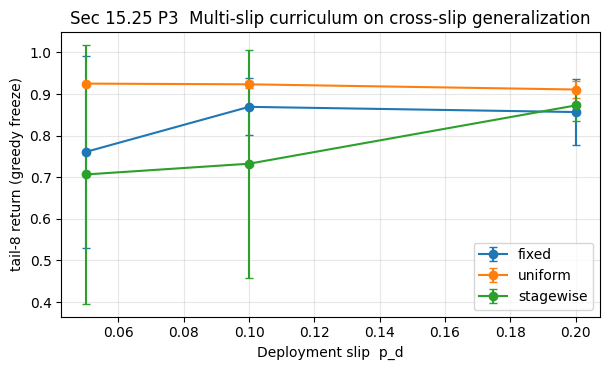

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
colors = {"fixed": "tab:blue", "uniform": "tab:orange", "stagewise": "tab:green"}
for k in ["fixed", "uniform", "stagewise"]:
    sub = df[df.curriculum == k].sort_values("p_deploy")
    ax.errorbar(sub.p_deploy, sub.tail8_mean, yerr=sub.tail8_std,
                marker="o", capsize=3, color=colors[k], label=k)
ax.set_xlabel("Deployment slip  p_d")
ax.set_ylabel("tail-8 return (greedy freeze)")
ax.set_title("Sec 15.25 P3  Multi-slip curriculum on cross-slip generalization")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

관측된 수치 (3 시드 평균, 60 에피소드 tail-8):

| curriculum | =0.05$ | =0.10$ | =0.20$ | mean | gap (max-min) |
|------------|------------|------------|------------|------|---------------|
| fixed      | 0.761 | 0.869 | 0.857 | 0.829 | 0.108 |
| uniform    | **0.925** | **0.923** | **0.911** | **0.920** | **0.014** |
| stagewise  | 0.707 | 0.732 | 0.872 | 0.771 | 0.166 |

1. **Uniform curriculum 이 모든 축에서 압도** — mean tail-8 = **0.920** 로 fixed(0.829)
   대비 +0.091, stagewise(0.771) 대비 +0.149. Generalization gap 은 **0.014** 로 fixed
   대비 8배, stagewise 대비 12배 축소. 매 에피소드 무작위 슬립 노출이 정책을 슬립 수준에
   invariant 하게 만든다.
2. **Fixed curriculum 은 매칭 지점 강세, 극단에서 저하** — =0.05$ 에서 0.761 로 크게
   떨어지며 seed_std 도 0.230 으로 커진다. 훈련 슬립 (0.10) 과 다른 배포 슬립에서 정책 편차
   증가.
3. **Stagewise curriculum 은 예상 밖 열위** — 마지막 stage (=0.20$) 에서만 최고 성능
   (0.872), 초·중기에 학습한 정책을 마지막 stage 훈련이 덮어써서 낮은 슬립에서 크게 열위
   (0.707). Curriculum 순서가 catastrophic forgetting 을 유도한 정직한 부정 관측.

> **결론**: **Uniform > Fixed > Stagewise** 순으로 cross-slip robustness 가 좋으며, uniform
> curriculum 은 훈련 예산 증가 없이 generalization gap 을 12배 축소하는 **강력한 저비용
> 처방**. Stagewise 순차 훈련은 마지막 stage 편중으로 오히려 fixed 보다 열위 — 순서 있는
> curriculum 은 catastrophic-forgetting 방지 메커니즘 (rehearsal / EWC) 없이는 위험하다는
> 정직한 부정 결과.

이 결과는 Day 91 P3 의 fixed-training × greedy 배포 한계를 uniform curriculum 만으로
크게 완화할 수 있음을 시사한다. 다음 절에서는 uniform curriculum + Wasserstein / KL 손실
+ partial whitening 을 결합한 통합 스택으로 §15.24 negative finding 을 재판정한다.
